In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

sentiment =  pd.read_csv("./fear_greed_index.csv")
trades = pd.read_csv("./historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [12]:
print(sentiment.info())
print(trades.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [3]:
print(sentiment.describe())
print(trades.describe())

          timestamp        value
count  2.644000e+03  2644.000000
mean   1.631899e+09    46.981089
std    6.597967e+07    21.827680
min    1.517463e+09     5.000000
25%    1.574811e+09    28.000000
50%    1.631900e+09    46.000000
75%    1.688989e+09    66.000000
max    1.746164e+09    95.000000
       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Time

In [13]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [14]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [24]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['time'] = pd.to_datetime(trades['Timestamp'], unit='ms')

trades['date'] = trades['time'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

print(trades[['Timestamp', 'time', 'date']].head())

      Timestamp                time       date
0  1.730000e+12 2024-10-27 03:33:20 2024-10-27
1  1.730000e+12 2024-10-27 03:33:20 2024-10-27
2  1.730000e+12 2024-10-27 03:33:20 2024-10-27
3  1.730000e+12 2024-10-27 03:33:20 2024-10-27
4  1.730000e+12 2024-10-27 03:33:20 2024-10-27


In [25]:
df = trades.merge(sentiment, on='date', how='left')

print(df.head())
print(df['classification'].value_counts())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ... Crossed       Fee      Trade ID     Timestamp  \
0         0.0  ...    True  0.345404

In [35]:
df['win'] = df['Closed PnL'] > 0

df['abs_pnl'] = df['Closed PnL'].abs()

print(df[['Closed PnL','win','Size USD']].head())

   Closed PnL    win  Size USD
0         0.0  False   7872.16
1         0.0  False    127.68
2         0.0  False   1150.63
3         0.0  False   1142.04
4         0.0  False     69.75


In [27]:
pnl_by_sentiment = df.groupby('classification')['Closed PnL'].mean().sort_values()
print(pnl_by_sentiment)

classification
Neutral          22.229713
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Name: Closed PnL, dtype: float64


In [28]:
win_rate = df.groupby('classification')['win'].mean().sort_values()
print(win_rate)

classification
Neutral          0.317182
Fear             0.415146
Greed            0.446471
Extreme Greed    0.490089
Name: win, dtype: float64


In [29]:
trade_volume = df.groupby('classification')['Size USD'].mean().sort_values()
print(trade_volume)

classification
Neutral          3058.848110
Greed            3182.883845
Fear             5259.977837
Extreme Greed    5660.265764
Name: Size USD, dtype: float64


In [30]:
risk = df.groupby('classification')['Closed PnL'].std().sort_values()
print(risk)

classification
Extreme Greed     306.166937
Neutral           633.704815
Fear              909.121796
Greed            1148.343968
Name: Closed PnL, dtype: float64


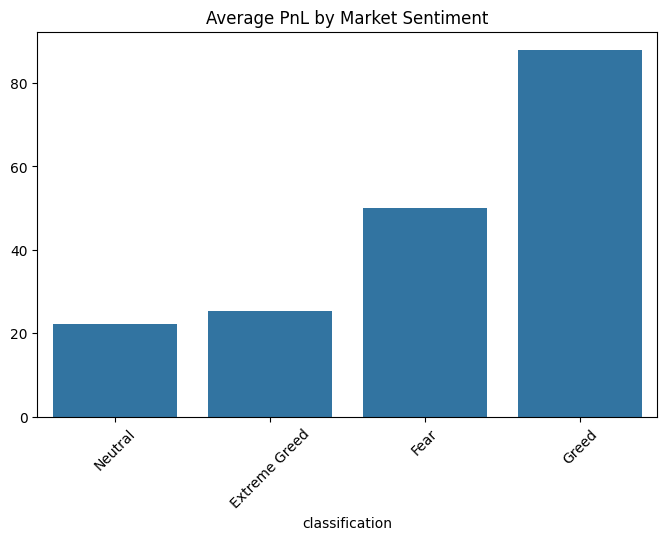

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x=pnl_by_sentiment.index, y=pnl_by_sentiment.values)
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

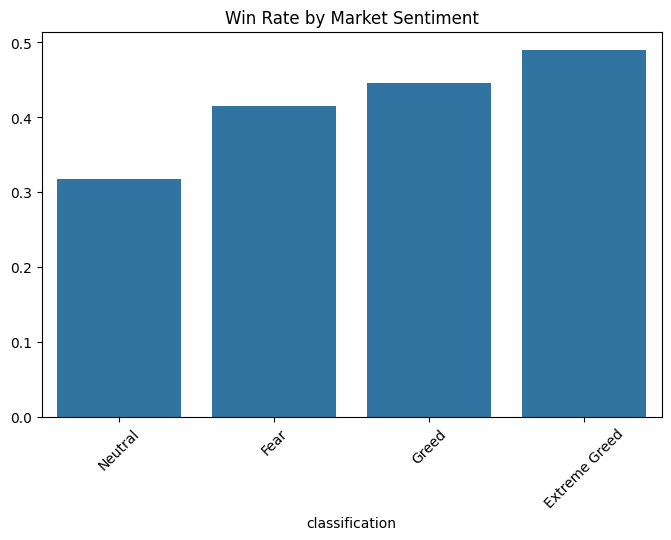

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

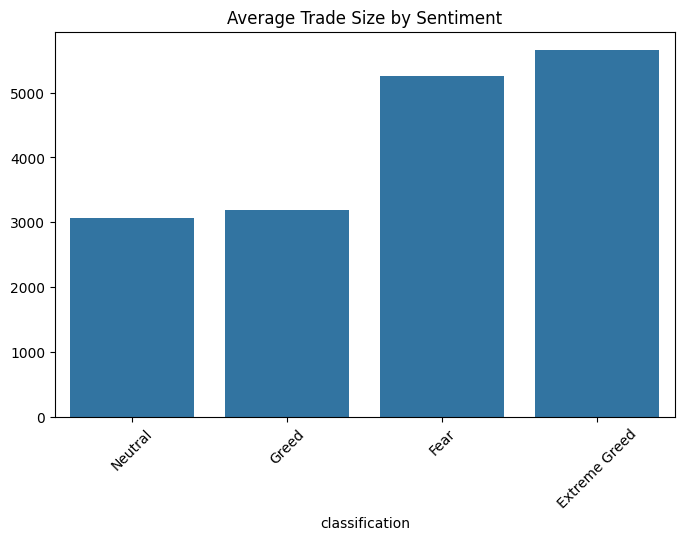

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x=trade_volume.index, y=trade_volume.values)
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

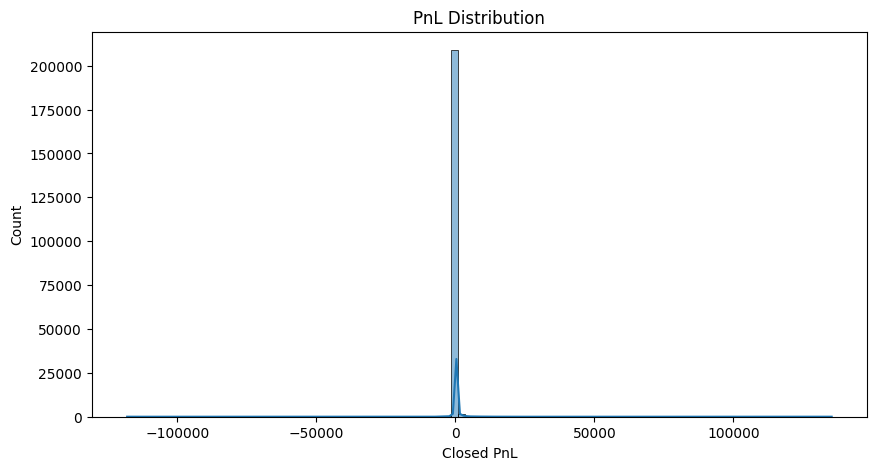

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(df['Closed PnL'], bins=100, kde=True)
plt.title("PnL Distribution")
plt.show()

<!-- Final Summary -->

In [ ]:
# 📊 Final Summary: Bitcoin Sentiment vs Trader Performance Analysis

## Objective
This project analyzes the relationship between Bitcoin market sentiment (Fear, Greed, Neutral, Extreme Greed) and trader performance using historical Hyperliquid trading data.

---

##  Key Findings

### 1. Profitability by Sentiment
- Traders achieve highest average PnL during **Greed** phases.
- Neutral markets show the lowest profitability.

### 2. Win Rate Pattern
- Win rate increases steadily from Neutral → Fear → Greed → Extreme Greed.
- Extreme Greed shows the highest win frequency.

### 3. Risk Behavior
- Greed phases show the highest volatility in returns.
- Extreme Greed shows lower volatility but more consistent outcomes.

### 4. Trading Activity
- Trade size increases significantly during Fear and Extreme Greed periods.
- Indicates higher risk-taking in emotionally extreme markets.

---

## Key Insight
Market sentiment strongly influences trader behavior. As sentiment becomes more extreme, traders increase position sizes and risk exposure. However, profitability does not always increase proportionally, indicating inefficiencies in emotional trading behavior.

---

##  Conclusion
Sentiment is a meaningful signal for understanding trader psychology and performance. Greed phases offer the best profitability, while Extreme Greed drives higher participation but not necessarily higher returns. This suggests that optimal trading strategies should adjust risk exposure based on sentiment regimes.

---

##  Recommendation
Traders should reduce position sizes during Extreme Greed conditions to avoid overexposure and focus on Greed phases for better risk-adjusted returns.